# Automobile MPG Dataset - Análise Exploratória

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

os.makedirs("graficos", exist_ok=True)
os.makedirs("tabelas", exist_ok=True)

/home/mrpunkdasilva/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("yasserh/auto-mpg-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(path + "/auto-mpg.csv")
df.columns = df.columns.str.replace(" ", "_")
df.head().to_csv("tabelas/auto-mpg_primeiras_linhas.csv", index=False)
df.head()

Path to dataset files: /home/mrpunkdasilva/.cache/kagglehub/datasets/yasserh/auto-mpg-dataset/versions/1


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
df.shape

(398, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df.describe().to_csv("tabelas/auto-mpg_estatisticas.csv")
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
null_counts = df.isnull().sum()
null_counts.to_csv("tabelas/auto-mpg_valores_nulos.csv", header=["valores_nulos"])
print(null_counts)

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [7]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

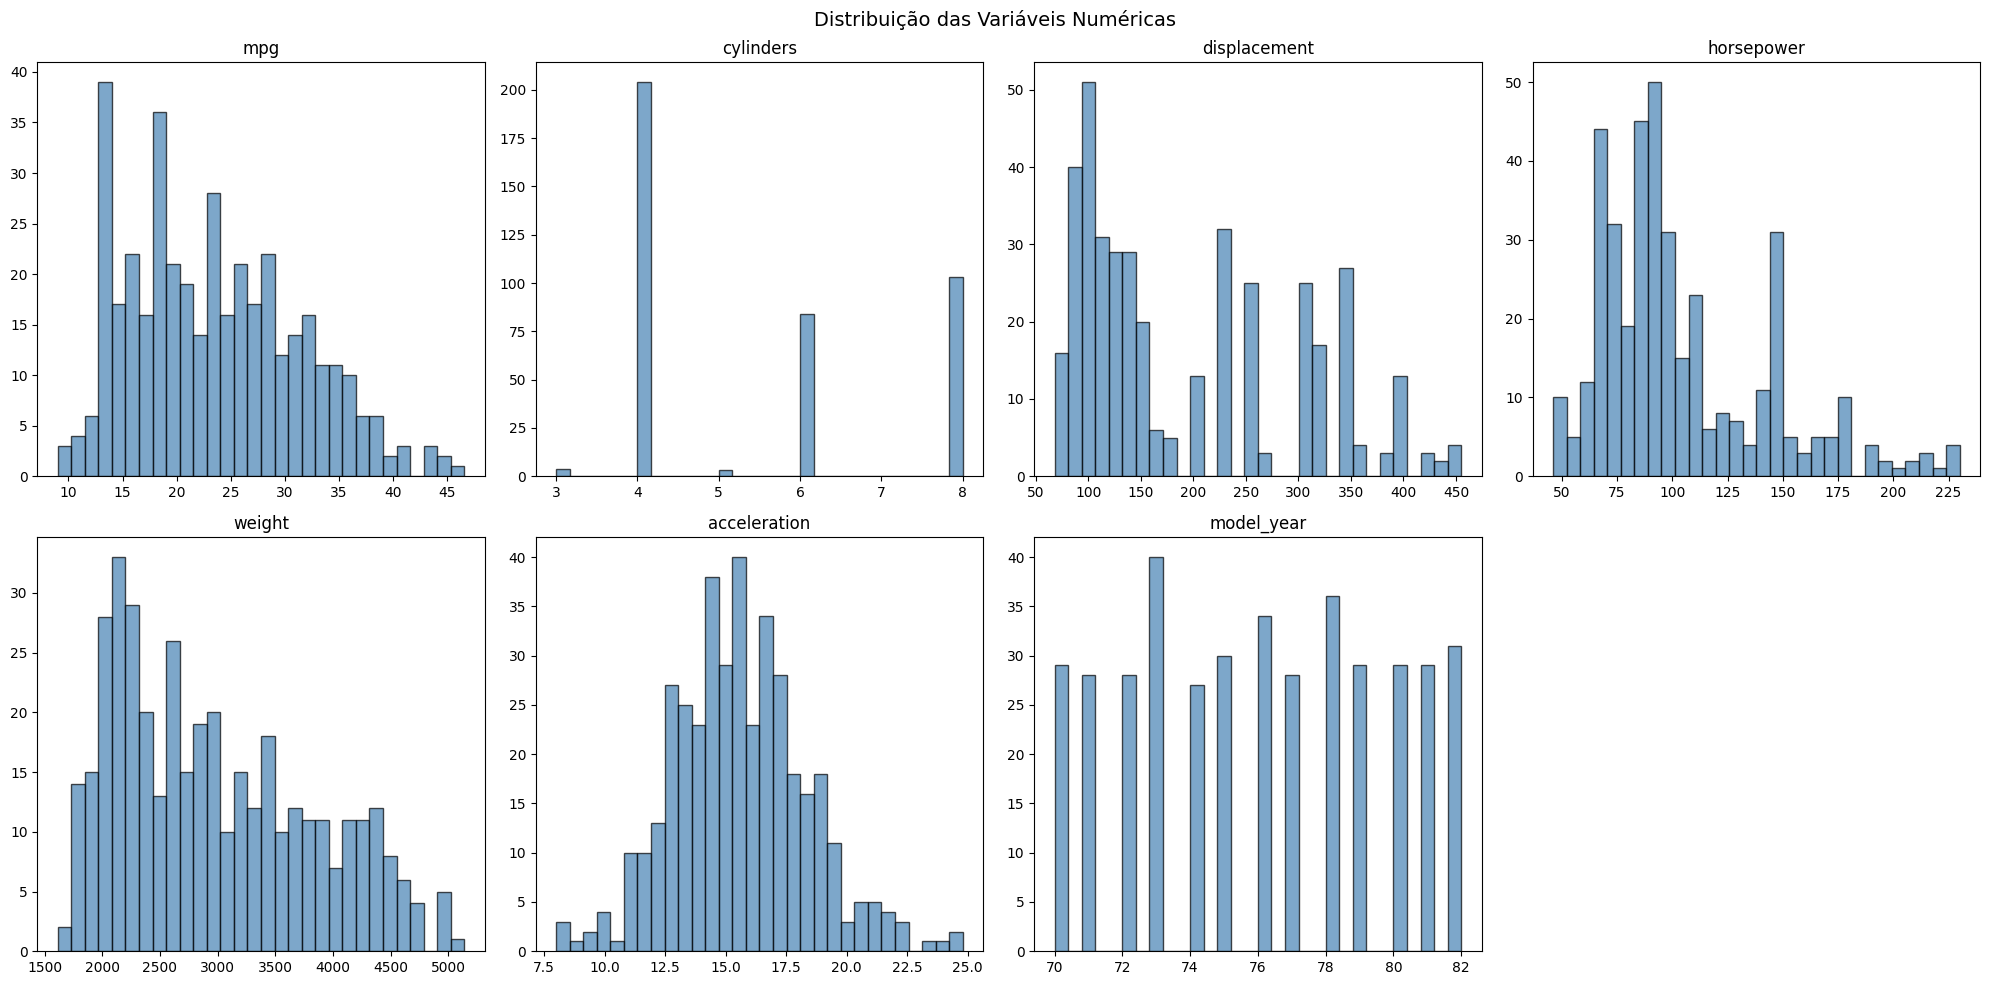

In [8]:
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(numeric_cols):
    row, c = i // 4, i % 4
    ax = axes[row, c]
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(col)
axes[1, 3].axis("off")
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/auto-mpg_histogramas_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()

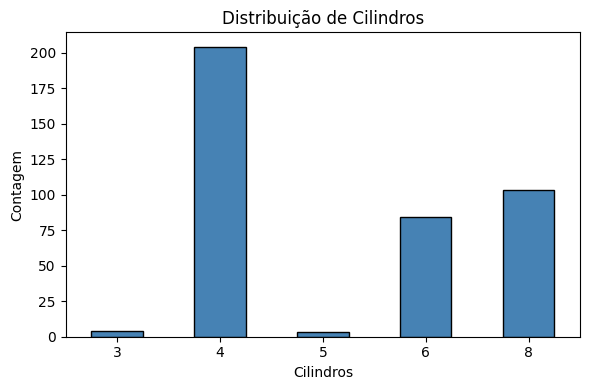

In [9]:
plt.figure(figsize=(6, 4))
df["cylinders"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribuição de Cilindros")
plt.xlabel("Cilindros")
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("graficos/auto-mpg_distribuicao_cilindros.png", dpi=150, bbox_inches="tight")
plt.show()

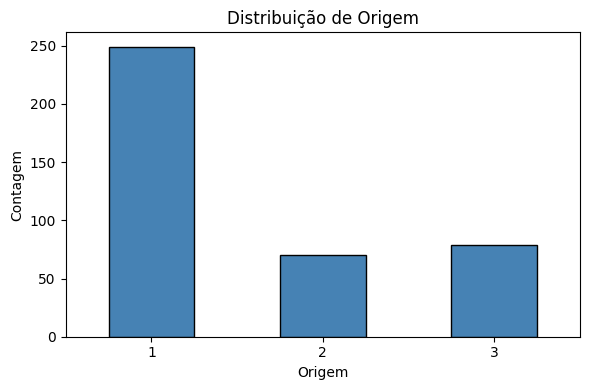

In [10]:
plt.figure(figsize=(6, 4))
df["origin"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribuição de Origem")
plt.xlabel("Origem")
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("graficos/auto-mpg_distribuicao_origem.png", dpi=150, bbox_inches="tight")
plt.show()

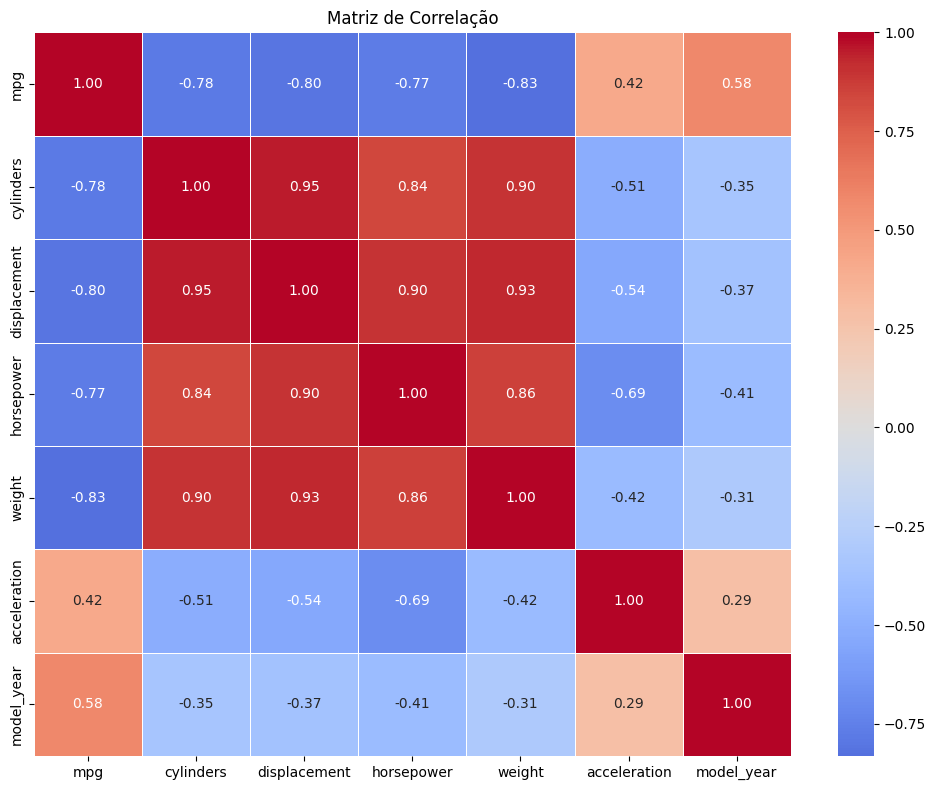

In [11]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.savefig("graficos/auto-mpg_matriz_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
corr_with_mpg = corr_matrix["mpg"].drop("mpg")
corr_with_mpg.sort_values(ascending=False).to_csv("tabelas/auto-mpg_correlacao_mpg.csv", header=["correlacao"])
print(corr_with_mpg.sort_values(ascending=False))

model_year      0.579267
acceleration    0.420289
horsepower     -0.773453
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


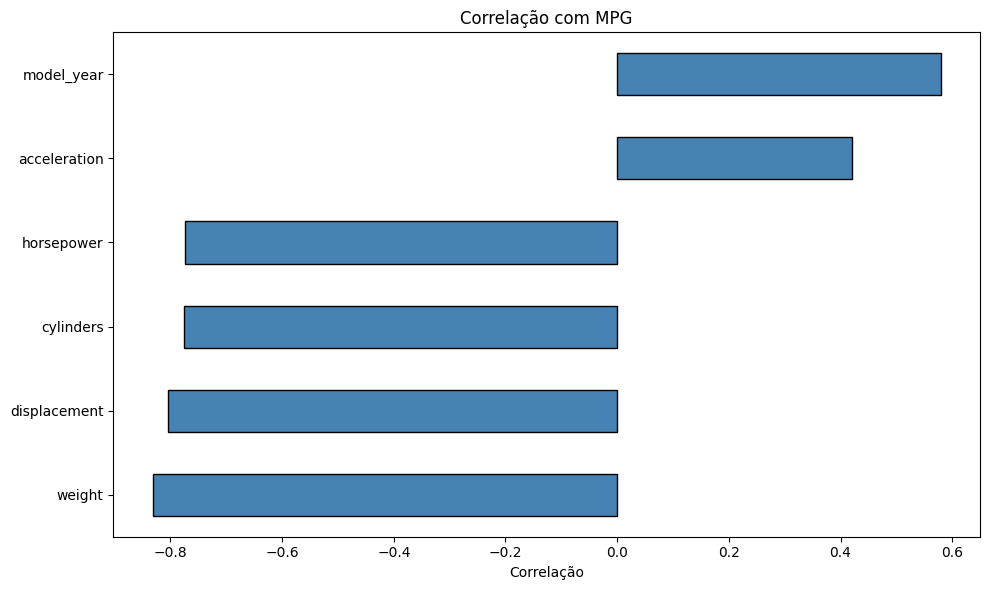

In [13]:
plt.figure(figsize=(10, 6))
corr_with_mpg.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Correlação com MPG")
plt.xlabel("Correlação")
plt.tight_layout()
plt.savefig("graficos/auto-mpg_correlacao_com_mpg.png", dpi=150, bbox_inches="tight")
plt.show()

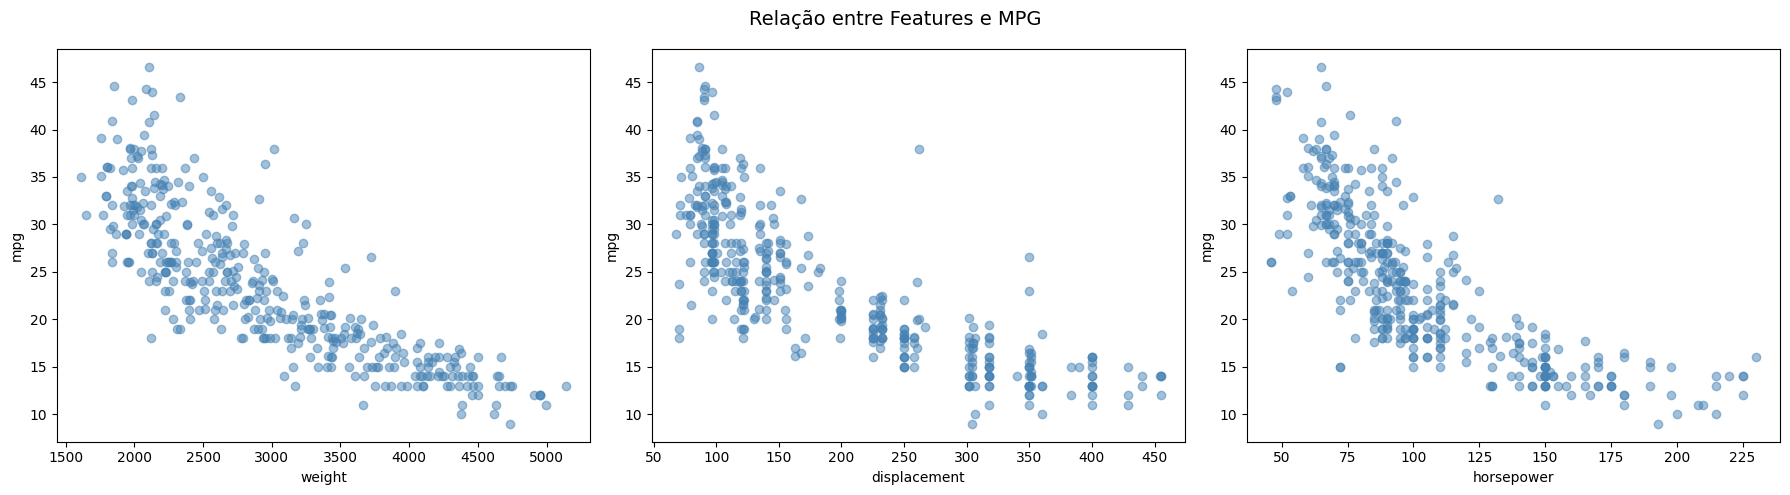

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_feats = [("weight", "mpg"), ("displacement", "mpg"), ("horsepower", "mpg")]
for i, (x, y) in enumerate(scatter_feats):
    ax = axes[i]
    ax.scatter(df[x], df[y], alpha=0.5, color="steelblue")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
plt.suptitle("Relação entre Features e MPG", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/auto-mpg_scatter_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_feats = [("weight", "mpg"), ("displacement", "mpg"), ("horsepower", "mpg")]
for i, (x, y) in enumerate(scatter_feats):
    ax = axes[i]
    for origin, color in [(1, "steelblue"), (2, "salmon"), (3, "darkorange")]:
        subset = df[df["origin"] == origin]
        ax.scatter(subset[x], subset[y], alpha=0.5, label=str(origin))
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title="Origem")
plt.suptitle("Relação entre Features e MPG por Origem", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/auto-mpg_scatter_por_origem.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(["cylinders", "model_year", "origin"]):
    ax = axes[i]
    df.boxplot(column="mpg", by=feat, ax=ax)
    ax.set_title(f"MPG por {feat}")
    ax.set_xlabel(feat)
plt.suptitle("Boxplots de MPG por Variáveis Categóricas", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/auto-mpg_boxplots_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["mpg"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(df["mpg"].mean(), color="red", linestyle="--", label=f"Media: {df['mpg'].mean():.2f}")
plt.axvline(df["mpg"].median(), color="green", linestyle="--", label=f"Mediana: {df['mpg'].median():.2f}")
plt.title("Distribuição de MPG")
plt.xlabel("MPG")
plt.ylabel("Contagem")
plt.legend()
plt.tight_layout()
plt.savefig("graficos/auto-mpg_distribuicao_mpg.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
summary = (
    "A análise exploratória do Automobile MPG Dataset revelou que peso, deslocamento e potência são as "
    "variáveis com maior correlação negativa com MPG (r = -0.83, -0.80 e -0.78 respectivamente), "
    "indicando que carros mais pesados e potentes consomem mais combustível. O ano do modelo apresenta "
    "correlação positiva moderada (r = 0.58), sugerindo melhoria na eficiência ao longo do tempo. "
    "A aceleração tem correlação positiva fraca (r = 0.42) com MPG. A origem do veículo influencia "
    "o consumo, com carros de origem europeia e japonesa apresentando MPG médio superior. "
    "A distribuição de MPG é assimétrica à direita com média de 23.51 e mediana de 23.0. "
    "Os boxplots mostram que carros com menos cilindros tendem a ter maior MPG, e que "
    "a eficiência melhorou significativamente entre os anos 70 e 80."
)
print(summary)